In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [4]:
# STUDY_NRS = ["s214696", "s224184", "s224223"]
STUDY_NRS = ["s224184"]

MALE_END = "face_00.5.png"    # the adaptor at the male end of our continuum
FEMALE_END = "face_05.5.png"  # the adaptor at the female end

CONF = 0.95  # confidence level used everywhere below
N_BOOT = 10000  # how many times we resample the data to build a confidence interval
RNG = np.random.default_rng(0)  # fixed seed so the numbers in the report do not change every time we run this

# The saved files have one row per condition and the ten ratings spread across ten columns.
# Here we stack them into one long table with a single rating per row, which is easier to plot and to average over.
frames = []
for nr in STUDY_NRS:
    df = pd.read_csv(f"experiment_3_{nr}_1.csv")
    rating_cols = df.filter(like="rating_").columns
    long = df.melt(
        id_vars=["adapting_image", "test_image"],
        value_vars=rating_cols,
        value_name="rating",
    ).dropna(subset=["rating"])
    long["participant"] = nr
    frames.append(long)

data = pd.concat(frames, ignore_index=True)

# The filename of a test face contains the rating the model was asked to produce, so we pull it out and use it as the label on the x-axis.
data["test_level"] = data["test_image"].str[5:-4].astype(float)
data["rating"] = data["rating"].astype(float)

print(data.groupby(["participant", "adapting_image"])["rating"].count())

participant  adapting_image
s224184      face_00.5.png     15
             face_05.5.png     15
Name: rating, dtype: int64


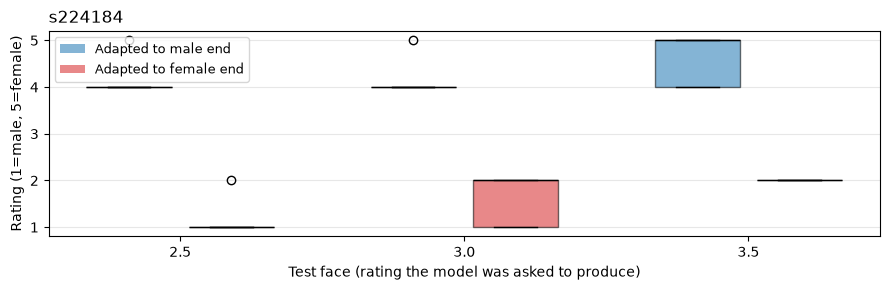

In [5]:
# This is the figure the assignment asks for: the three test faces, with the two adaptation conditions shown side by side so the shift can be read off directly.
# One row per participant, because the size of an after-effect is very personal and averaging across people can hide it.

levels = sorted(data["test_level"].unique())
colors = {MALE_END: "tab:blue", FEMALE_END: "tab:red"}
labels = {MALE_END: "Adapted to male end", FEMALE_END: "Adapted to female end"}

fig, axes = plt.subplots(len(STUDY_NRS), 1, figsize=(9, 3 * len(STUDY_NRS)), sharex=True, sharey=True)

for ax, nr in zip(np.atleast_1d(axes), STUDY_NRS):
    person = data[data["participant"] == nr]

    for offset, adaptor in [(-0.18, MALE_END), (0.18, FEMALE_END)]:
        # The two boxes for the same test face are nudged left and right of the tick, so they sit next to each other instead of on top of each other.
        boxes = [person[(person["adapting_image"] == adaptor) & (person["test_level"] == lvl)]["rating"].values
                 for lvl in levels]
        bp = ax.boxplot(boxes, positions=[i + offset for i in range(len(levels))],
                        widths=0.3, patch_artist=True, manage_ticks=False)
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[adaptor])
            patch.set_alpha(0.55)
        for median in bp["medians"]:
            median.set_color("black")

    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([f"{lvl:.1f}" for lvl in levels])
    ax.set_ylabel("Rating (1=male, 5=female)")
    ax.set_title(nr, loc="left")
    ax.grid(axis="y", alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[a], alpha=0.55) for a in (MALE_END, FEMALE_END)]
np.atleast_1d(axes)[0].legend(handles, [labels[MALE_END], labels[FEMALE_END]], loc="upper left", fontsize=9)
np.atleast_1d(axes)[-1].set_xlabel("Test face (rating the model was asked to produce)")

plt.tight_layout()
plt.savefig("experiment3_boxplots.png", dpi=200)
plt.show()

In [6]:
# The prediction is that perception is pushed AWAY from whatever was adapted to.
# So after staring at e.g. the male end, the same test face should look more female (higher rating) than it does after staring at the female end.
# A positive difference below means the after-effect went the predicted way.

means = data.pivot_table(index=["participant", "test_level"],
                         columns="adapting_image", values="rating", aggfunc="mean")
means["difference"] = means[MALE_END] - means[FEMALE_END]
means["as predicted"] = np.where(means["difference"] > 0, "yes", "no")

print(means.round(2).to_string())
print(f"\n{(means['difference'] > 0).sum()} of {len(means)} test-face/participant combinations "
      "went in the predicted direction")

adapting_image          face_00.5.png  face_05.5.png  difference as predicted
participant test_level                                                       
s224184     2.5                   4.2            1.2         3.0          yes
            3.0                   4.2            1.6         2.6          yes
            3.5                   4.6            2.0         2.6          yes

3 of 3 test-face/participant combinations went in the predicted direction
